In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from libpysal.weights import lat2W
from esda.moran import Moran

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
np.random.seed(42)

GRID_SIZE = 25

x, y = np.indices((GRID_SIZE, GRID_SIZE))

center = (x.mean(), y.mean())
dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)

income = 60000 + dist * 3000 + np.random.normal(0, 4000, x.shape)
building_age = 70 - dist * 5 + np.random.normal(0, 7, x.shape)
density = 1200 + (1/(dist+1))*600 + np.random.normal(0, 60, x.shape)
green = np.maximum(0, 60 - dist*2 + np.random.normal(0, 8, x.shape))
industrial = np.random.uniform(0, 120, x.shape)
temperature = 25 + dist * 0.8 + np.random.normal(0, 1, x.shape)

In [4]:
risk = (
    building_age * 0.7
    - income * 0.0005
    + density * 0.003
    - green * 0.12
    + industrial * 0.06
    + temperature * 1.2
    + 25
)

energy_risk = (risk + np.random.normal(0, 2, risk.shape)).flatten()

In [5]:
df = pd.DataFrame({
    "income": income.flatten(),
    "building_age": building_age.flatten(),
    "density": density.flatten(),
    "green": green.flatten(),
    "industrial": industrial.flatten(),
    "temperature": temperature.flatten(),
    "distance": dist.flatten()
})

df.head()

,income,building_age,density,green,industrial,temperature,distance
0,112898.544857,-18.431323,1253.240750,37.224345,97.695082,38.510476,16.970563
1,108283.404584,-18.321337,1284.736330,22.945015,82.216117,38.473712,16.278821
2,109452.252208,-8.983005,1116.475860,27.085226,13.251824,37.065685,15.620499
3,111092.119426,-4.609926,1259.943394,16.532494,34.702494,36.853940,15.000000
4,102330.001807,5.548315,1312.565082,24.708629,37.176825,36.667265,14.422205


In [6]:
df["income_age"] = df["income"] * df["building_age"]
df["density_green"] = df["density"] / (df["green"] + 1)
df["heat_index"] = df["temperature"] * df["density"]
df["industrial_pressure"] = df["industrial"] * df["density"]
df["socio_index"] = df["income"] / (df["density"] + 1)

df.head()

,income,building_age,density,green,industrial,temperature,distance,income_age,density_green,heat_index,industrial_pressure,socio_index
0,112898.544857,-18.431323,1253.240750,37.224345,97.695082,38.510476,16.970563,-2.080870e+06,32.786455,48262.897296,122435.458176,90.013456
1,108283.404584,-18.321337,1284.736330,22.945015,82.216117,38.473712,16.278821,-1.983897e+06,53.653604,49428.575596,105626.032656,84.218982
2,109452.252208,-8.983005,1116.475860,27.085226,13.251824,37.065685,15.620499,-9.832102e+05,39.753137,41382.942287,14795.341159,97.945966
3,111092.119426,-4.609926,1259.943394,16.532494,34.702494,36.853940,15.000000,-5.121264e+05,71.863328,46433.878398,43723.177517,88.102384
4,102330.001807,5.548315,1312.565082,24.708629,37.176825,36.667265,14.422205,5.677591e+05,51.055428,48128.171073,48797.002401,77.902498


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

In [10]:
from libpysal.weights import lat2W
from esda.moran import Moran

w = lat2W(GRID_SIZE, GRID_SIZE)
w.transform = 'R'

moran = Moran(energy_risk, w)

print("Moran I:", moran.I)
print("p-value:", moran.p_sim)

Moran I: 0.8244026385268328
p-value: 0.001


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_scaled, energy_risk, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 2.708506412651761


In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters

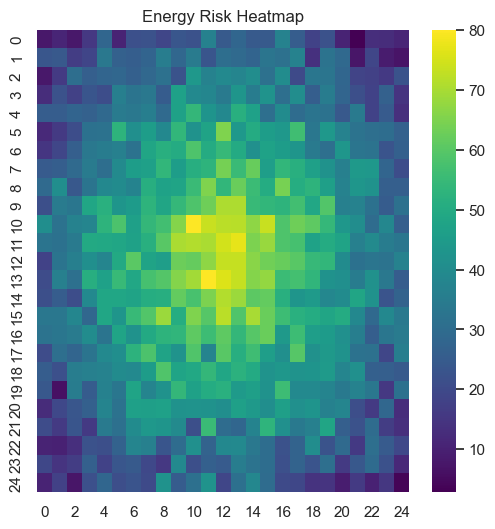

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.heatmap(energy_risk.reshape(GRID_SIZE, GRID_SIZE), cmap="viridis")
plt.title("Energy Risk Heatmap")
plt.show()

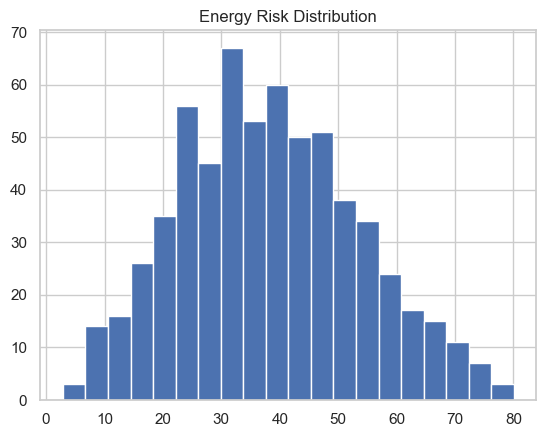

In [14]:
plt.hist(energy_risk, bins=20)
plt.title("Energy Risk Distribution")
plt.show()

In [15]:
df.to_csv("urban_energy_data.csv", index=False)